In [2]:
#!pip install rdkit selfies

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 51.7 MB/s eta 0:00:00


In [3]:
import ast
import re
import numpy as np
import pandas as pd
from rdkit import Chem
import tensorflow as tf
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
!git clone https://github.com/ElTragedy/capstone.git /content/drive/MyDrive/capstone
%cd /content/drive/MyDrive/capstone

Cloning into '/content/drive/MyDrive/capstone'...
remote: Enumerating objects: 184, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 184 (delta 1), reused 1 (delta 1), pack-reused 179 (from 1)
Receiving objects: 100% (184/184), 54.43 MiB | 19.66 MiB/s, done.
Resolving deltas: 100% (90/90), done.
Updating files: 100% (35/35), done.
/content/drive/MyDrive/capstone


In [5]:
#use in get_data.py
def normalize_graph_features(x):
    x = re.sub(r'(?<=[0-9])\s+(?=[0-9])', ',', x)
    x = re.sub(r'\]\s+\[', '],[', x)
    return x

In [6]:
def preprocess_node_features(node_features_list, valid_atom_types, num_nodes):
    num_features = len(valid_atom_types)
    one_hot_features = np.zeros((num_nodes, num_features))

    atom_type_to_index = {atom: idx for idx, atom in enumerate(valid_atom_types)}

    for i, atom in enumerate(node_features_list):
        if atom[0] in atom_type_to_index:
            one_hot_features[i, atom_type_to_index[atom[0]]] = 1

    return one_hot_features

In [7]:
def pad_adj_matrix(matrix, max_size):
    padded_matrix = np.zeros((max_size, max_size))
    n, m = matrix.shape
    padded_matrix[:n, :m] = matrix
    return padded_matrix

In [8]:
def create_dataset(adj_matrices, one_hot_node_features, batch_size=32):
    dataset = tf.data.Dataset.from_tensor_slices((one_hot_node_features, adj_matrices))
    dataset = dataset.shuffle(buffer_size=len(one_hot_node_features)).batch(batch_size)
    return dataset

In [9]:
def pad_one_hot_features(features, max_size, num_features):
    padded_features = np.zeros((max_size, num_features))
    n, _ = features.shape
    padded_features[:n, :] = features
    return padded_features

In [10]:
qm9 = pd.read_csv("Data/qm9.csv")
qm9.tail()

,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom,Morgan_fingerprint,adj_matrix,node_features,node_count
133880,gdb_133881,C1C2C3C4C5OC14C5N23,3.59483,2.19899,1.90423,1.6637,69.37,-0.2254,0.0588,0.2842,...,-400.663098,23.658,-1603.983913,-1614.898804,-1623.788097,-1492.819438,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 0 0 0 1]\n [...,"[[6], [6], [6], [6], [6], [8], [6], [6], [7]]",9
133881,gdb_133882,C1N2C3C2C2C4OC12C34,3.65648,2.14237,1.90439,1.2976,69.52,-0.2393,0.0608,0.3002,...,-400.658942,23.697,-1601.376613,-1612.291504,-1621.181424,-1490.211511,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 0 1 0]\n [1 0 1 1 0 0 0 0 0]\n [...,"[[6], [7], [6], [6], [6], [6], [8], [6], [6]]",9
133882,gdb_133883,C1N2C3C4C5C2C13CN45,3.67118,2.14314,1.89501,1.2480,73.60,-0.2233,0.0720,0.2953,...,-380.783148,23.972,-1667.045429,-1678.830048,-1688.312964,-1549.143391,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 1 0 0 0]\n [...,"[[6], [7], [6], [6], [6], [6], [6], [6], [7]]",9
133883,gdb_133884,C1N2C3C4C5CC13C2C45,3.52845,2.15131,1.86582,1.9576,77.40,-0.2122,0.0881,0.3003,...,-364.749650,24.796,-1794.600439,-1807.210860,-1817.286772,-1670.349892,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 0 0 1 0]\n [...,"[[6], [7], [6], [6], [6], [6], [6], [6], [6]]",9
133884,gdb_133885,C1N2C3C4C5OC13C2C45,3.64015,2.21764,1.93793,0.8626,69.48,-0.2316,0.0742,0.3058,...,-400.662186,23.434,-1603.471865,-1614.455155,-1623.345075,-1492.247150,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 0 0 1 0]\n [...,"[[6], [7], [6], [6], [6], [8], [6], [6], [6]]",9


In [11]:
#use in get_data.py
qm9['adj_matrix'] = qm9["adj_matrix"].apply(normalize_graph_features)
qm9['node_features'] = qm9["node_features"].apply(normalize_graph_features)

In [12]:
#use in get_data.py
qm9['adj_matrix'] = qm9['adj_matrix'].apply(lambda x: np.array(ast.literal_eval(x)))
qm9['node_features'] = qm9['node_features'].apply(lambda x: ast.literal_eval(x))

In [13]:
valid_atom_types = [1, 6, 7, 8, 9]
num_features = len(valid_atom_types)

one_hot_node_features = [
    preprocess_node_features(nf, valid_atom_types, num_nodes)
    for nf, num_nodes in zip(qm9['node_features'], qm9['node_count'])
]

In [14]:
max_size = max(matrix.shape[0] for matrix in qm9['adj_matrix'])
qm9['adj_matrix'] = qm9['adj_matrix'].apply(lambda x: pad_adj_matrix(x, max_size))

In [15]:
one_hot_node_features = [
    pad_one_hot_features(features, max_size, num_features)
    for features in one_hot_node_features
]

In [16]:
adj_matrices = np.stack(qm9['adj_matrix'].values)
one_hot_node_features = np.stack(one_hot_node_features)

In [17]:
adj_matrices_small = adj_matrices[:1000]
one_hot_node_features_small = one_hot_node_features[:1000]

dataset_small = create_dataset(adj_matrices_small, one_hot_node_features_small, batch_size=32)

In [18]:
dataset = create_dataset(adj_matrices, one_hot_node_features, batch_size=32)

In [19]:
#gumbel-softmax function
def gumbel_softmax_sample(logits, tau=1.0, eps=1e-10):
    noise = tf.random.uniform(tf.shape(logits), minval=0, maxval=1)
    noise = -tf.math.log(-tf.math.log(noise + eps) + eps)
    return tf.nn.softmax((logits + noise) / tau, axis=-1)

In [20]:
class GraphGenerator(tf.keras.Model):
    def __init__(self, num_nodes, node_features, latent_dim):
        super().__init__()

        self.num_nodes = num_nodes
        self.node_features = node_features
        self.latent_dim = latent_dim

        self.mlp = models.Sequential([
            layers.Dense(128, input_shape=(latent_dim,), activation="relu"),
            layers.Dense(256, activation="relu"),
            layers.Dense((num_nodes * num_nodes) + (num_nodes * node_features), activation="softmax")
        ])

        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

    def call(self, z, tau=1.0):  #tau for gumbel-softmax
        batch_size = tf.shape(z)[0]

        output = self.mlp(z)

        adj_flat = output[:, :self.num_nodes * self.num_nodes]
        adj_flat = tf.nn.sigmoid(adj_flat)
        node_feature_flat = output[:, self.num_nodes * self.num_nodes:]

        adj = tf.reshape(adj_flat, (batch_size, self.num_nodes, self.num_nodes))
        adj = (adj + tf.transpose(adj, perm=[0, 2, 1])) / 2
        adj = tf.nn.softmax(adj, axis=-1)
        adj = tf.cast(adj, tf.float32)

        valid_atom_types = tf.constant([1, 6, 7, 8, 9], dtype=tf.int64)

        #gumbel-softmax incorporation
        node_features_logits = tf.reshape(node_feature_flat, (batch_size, self.num_nodes, self.node_features))
        node_features = gumbel_softmax_sample(node_features_logits, tau)
        node_features = tf.clip_by_value(node_features, 0, 4)
        node_features = tf.cast(node_features, tf.int32)
        node_features = tf.gather(valid_atom_types, node_features)
        node_features = tf.cast(node_features, tf.float32)

        return adj, node_features

    def loss_function(self, real_output, fake_output):
        loss_func = tf.keras.losses.BinaryCrossentropy(from_logits=False)
        return loss_func(real_output, fake_output)

    def fit(self, dataset, discriminator, epochs=10):
        d_loss_list = []
        g_loss_list = []

        for epoch in range(epochs):
            for batch_idx, (real_node_features, real_adj) in enumerate(dataset):
                z = tf.random.normal([tf.shape(real_node_features)[0], self.latent_dim])
                gen_adj, gen_node_features = self.call(z)

                with tf.GradientTape() as tape:
                    fake_output = discriminator.call(gen_adj, gen_node_features)
                    real_output = discriminator.call(real_adj, real_node_features)

                    # Label smoothing test
                    real_labels = tf.ones_like(real_output) * .9
                    fake_labels = tf.zeros_like(fake_output) + .1

                    # Label switching test
                    if np.random.rand() < .05:
                        real_labels, fake_labels = fake_labels, real_labels

                    d_loss = self.loss_function(real_labels, real_output) + \
                             self.loss_function(fake_labels, fake_output)

                    d_loss_list.append(d_loss.numpy())

                gradients = tape.gradient(d_loss, discriminator.mlp.trainable_variables)
                discriminator.optimizer.apply_gradients(zip(gradients, discriminator.mlp.trainable_variables))

                for _ in range(3):
                    z = tf.random.normal([tf.shape(real_node_features)[0], self.latent_dim])

                    with tf.GradientTape() as tape:
                        gen_adj, gen_node_features = self(z)
                        fake_output = discriminator(gen_adj, gen_node_features)
                        g_loss = self.loss_function(tf.ones_like(fake_output), fake_output)

                        g_loss_list.append(g_loss.numpy())

                    gradients = tape.gradient(g_loss, self.mlp.trainable_variables)
                    self.optimizer.apply_gradients(zip(gradients, self.mlp.trainable_variables))

                    if batch_idx % 10 == 0:
                        print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}, "
                              f"D Loss: {d_loss.numpy():.4f}, G Loss: {g_loss.numpy():.4f}")

        return d_loss_list, g_loss_list

In [21]:
class GraphDiscriminator(tf.keras.Model):
    def __init__(self, num_nodes, node_features):
        super().__init__()
        self.input_dim = num_nodes * num_nodes
        self.condition_dim = num_nodes * node_features

        self.mlp = models.Sequential([
            layers.Dense(256, input_shape=(self.input_dim + self.condition_dim,), activation='leaky_relu'),
            layers.Dense(128, activation='leaky_relu'),
            layers.BatchNormalization(),
            layers.Dense(1, activation='sigmoid')
        ])

        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

    def call(self, adj, node_features):
        batch_size = tf.shape(adj)[0]

        adj_flat = tf.reshape(adj, (batch_size, self.input_dim))
        node_features_flat = tf.reshape(node_features, (batch_size, self.condition_dim))

        combined = tf.concat([adj_flat, node_features_flat], axis=1)

        validity = self.mlp(combined)

        return validity

In [22]:
def adjacency_matrix_to_mol(inp_matrix):
    mol = Chem.RWMol()
    atom_types = np.unique(inp_matrix[1])
    matrix = inp_matrix[0]
    atom_map = {i: mol.AddAtom(Chem.Atom(int(atom_types[i]))) for i in range(len(atom_types))}

    if isinstance(matrix, tf.Tensor):
        matrix = matrix.numpy()
    if isinstance(atom_types, tf.Tensor):
        atom_types = atom_types.numpy()

    matrix = np.array(matrix)
    atom_types = np.array(atom_types)

    if len(matrix) != len(atom_types):
        raise ValueError("NUMBER OF ATOM TYPES DOES NOT MATCH MATRIX DIMENSIONS")

    # Step 1: Add Atoms
    for i, atom_num in enumerate(atom_types):
        atom = Chem.Atom(int(atom_num))
        mol_idx = mol.AddAtom(atom)
        atom_map[i] = mol_idx

    # Step 2: Add Bonds
    for i in range(len(matrix)):
        for j in range(i + 1, len(matrix)):
            if j not in atom_map:
                continue

            value = int(np.argmax(matrix[i, j]))
            value = min(max(value, 0), 4)

            if value != 0:
                bond_type = {
                    1: Chem.BondType.SINGLE,
                    2: Chem.BondType.DOUBLE,
                    3: Chem.BondType.TRIPLE,
                    4: Chem.BondType.AROMATIC
                }.get(value, None)

                if bond_type is None:
                    raise ValueError(f"INVALID BOND TYPE DETECTED: {value}")

                print(f"Adding bond: {i}-{j} Type: {bond_type}")
                mol.AddBond(atom_map[i], atom_map[j], bond_type)

    return mol

In [23]:
generator = GraphGenerator(num_nodes=max_size, node_features=num_features, latent_dim=128)
discriminator = GraphDiscriminator(num_nodes=max_size, node_features=num_features)

d_loss, g_loss = generator.fit(dataset_small, discriminator, epochs=10)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10, Batch 0, D Loss: 1.4345, G Loss: 1.0345
Epoch 1/10, Batch 0, D Loss: 1.4345, G Loss: 1.0345
Epoch 1/10, Batch 0, D Loss: 1.4345, G Loss: 1.0345
Epoch 1/10, Batch 10, D Loss: 0.9627, G Loss: 1.7395
Epoch 1/10, Batch 10, D Loss: 0.9627, G Loss: 1.7394
Epoch 1/10, Batch 10, D Loss: 0.9627, G Loss: 1.7394
Epoch 1/10, Batch 20, D Loss: 0.8314, G Loss: 1.6466
Epoch 1/10, Batch 20, D Loss: 0.8314, G Loss: 1.6466
Epoch 1/10, Batch 20, D Loss: 0.8314, G Loss: 1.6465
Epoch 1/10, Batch 30, D Loss: 0.7197, G Loss: 1.9965
Epoch 1/10, Batch 30, D Loss: 0.7197, G Loss: 1.9966
Epoch 1/10, Batch 30, D Loss: 0.7197, G Loss: 1.9965
Epoch 2/10, Batch 0, D Loss: 0.7098, G Loss: 2.0312
Epoch 2/10, Batch 0, D Loss: 0.7098, G Loss: 2.0312
Epoch 2/10, Batch 0, D Loss: 0.7098, G Loss: 2.0312
Epoch 2/10, Batch 10, D Loss: 0.6741, G Loss: 2.1490
Epoch 2/10, Batch 10, D Loss: 0.6741, G Loss: 2.1490
Epoch 2/10, Batch 10, D Loss: 0.6741, G Loss: 2.1490
Epoch 2/10, Batch 20, D Loss: 0.6779, G Loss: 2.0365

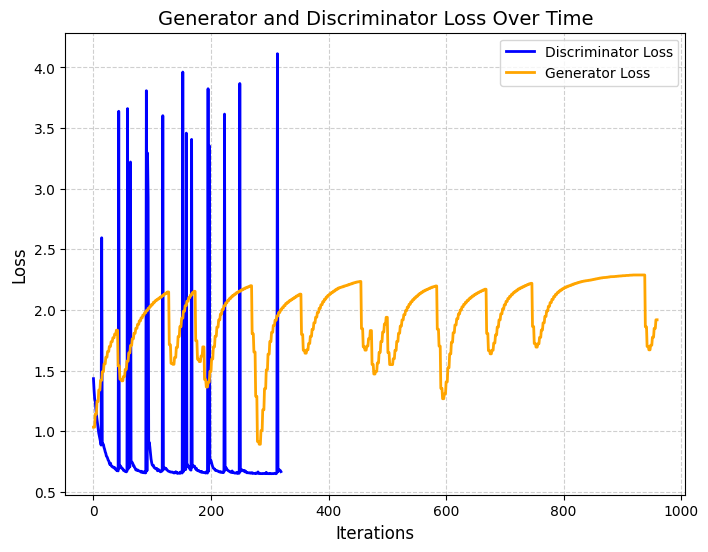

In [24]:
plt.figure(figsize=(8, 6))
plt.plot(d_loss, label="Discriminator Loss", color="blue", linewidth=2)
plt.plot(g_loss, label="Generator Loss", color="orange", linewidth=2)

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Generator and Discriminator Loss Over Time", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()